# qBraid QIR simulator batch job submission

In [1]:
from qbraid.runtime import QbraidProvider
from qbraid.visualization import plot_histogram
from qbraid.programs import QPROGRAM_REGISTRY

/Users/tarinihardikar/Desktop/qBraid-software/qbraid-lab-demo/.demo/lib/python3.12/site-packages/bloqade/analog/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
provider = QbraidProvider()

In [3]:
device = provider.get_device("qbraid:qbraid:sim:qir-sv")

device.status()

<DeviceStatus.ONLINE: 'ONLINE'>

In [4]:
target_spec = device.profile.get("program_spec")

target_spec

<ProgramSpec('builtins.str', 'qasm3')>

In [5]:
QPROGRAM_REGISTRY

{'cirq': cirq.circuits.circuit.Circuit,
 'qiskit': qiskit.circuit.quantumcircuit.QuantumCircuit,
 'braket': braket.circuits.circuit.Circuit,
 'braket_ahs': braket.ahs.analog_hamiltonian_simulation.AnalogHamiltonianSimulation,
 'openqasm3': openqasm3.ast.Program,
 'qasm3': str,
 'qasm2': str,
 'qasm2_kirin': str,
 'ionq': qbraid.programs.typer.IonQDict,
 'qubo': qbraid.programs.typer.QuboCoefficientsDict,
 'bloqade': bloqade.analog.builder.assign.BatchAssign,
 'stim': stim._stim_polyfill.Circuit,
 'pyqir': Module,
 'autoqasm': autoqasm.program.program.Program}

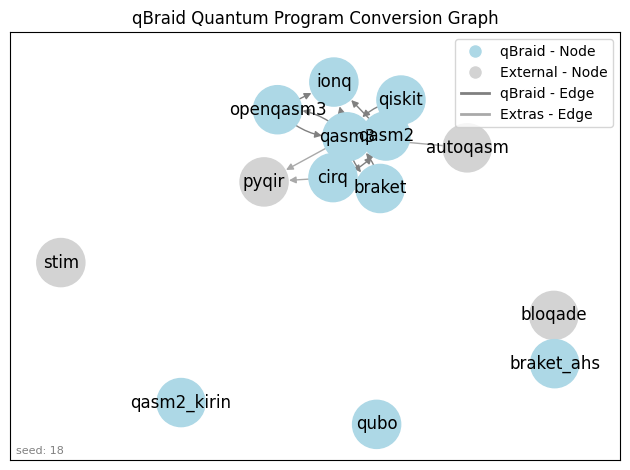

In [6]:
graph = device.scheme.conversion_graph

graph.plot(legend=True)

Create batch of GHZ state circuits using OpenQASM 3 and Cirq

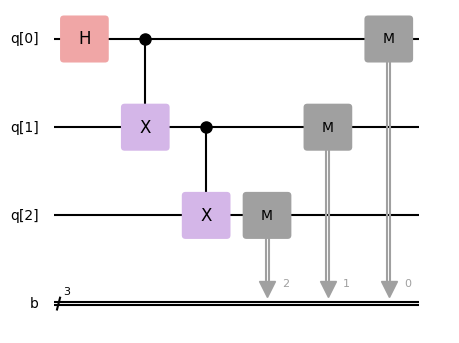

In [7]:
import cirq
import qiskit

from qbraid.visualization import circuit_drawer


def qasm3_ghz() -> str:
    return """
OPENQASM 3.0;
bit[3] b;
qubit[3] q;
h q[0];
cx q[0], q[1];
cx q[1], q[2];
b[0] = measure q[0];
b[1] = measure q[1];
b[2] = measure q[2];
    """


def cirq_ghz() -> cirq.Circuit:
    """Returns Cirq GHZ circuit"""
    q0, q1, q2 = cirq.LineQubit.range(3)
    circuit = cirq.Circuit(
        cirq.ops.H(q0),
        cirq.ops.CNOT(q0, q1),
        cirq.ops.CNOT(q1, q2),
        cirq.measure((q0, q1, q2), key="result"),
    )
    return circuit


circuits = [qasm3_ghz(), cirq_ghz()]

circuit_drawer(circuits[0])

Submit quantum jobs to remote qBraid QIR simulator and plot results

In [8]:
batch_jobs = device.run(circuits, shots=100)

In [9]:
for job in batch_jobs:
    print(job.status())

JobStatus.INITIALIZING
JobStatus.INITIALIZING


In [10]:
batch_results = [job.result() for job in batch_jobs]

batch_counts = [result.data.measurement_counts for result in batch_results]

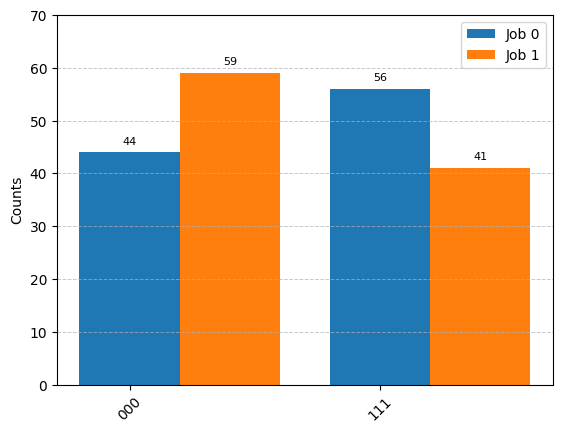

In [11]:
plot_histogram(batch_counts)